<img src="https://raw.githubusercontent.com/egiuse25/APS/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Emilia Giusepponi


# Consigna
## Ejercicio 1:  
Sintetizar:

    1. Señal sinusoidal de 2 KHz.

    2. Misma señal amplificada 3 dB y desfasada en π/2.

    3. Misma señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.

    4. Misma señal con efecto de saturación al 75% de su amplitud. Ayuda: ver numpy.clip().

    5. Una señal cuadrada de 4KHz.

    6. Un pulso rectangular de 10ms.

En cada caso indique: período, número de muestras y si se trata de una señal de potencia o energía según corresponda.
## Ejercicio 2: 

Dado h[n] = δ[n] - δ[n - 4], encontrar y[n] = x[n] * h[n] para cada una de las siguientes x[n]:

    a) x[n] = cos(ω₀.n. TS). Expresar la respuesta como un único coseno de la forma A cos(ω₀. n . TS + φ).

    b) x[n] = (1/2)ⁿ u[n].

    c) x[n] = u[n + 1] - u[n - 2].



# Desarrollo 
## Definición de función seno
Para empezar, se comienza definiendo la función seno dada por:
$$x(t) = DC + A \cdot \sin(2\pi \cdot f \cdot t + \phi)$$
Siendo en el código:

• Señal senoidal ($x(t)$) = `xx`.

• Desplazamiento en el eje Y (Valor medio) ($DC$) = `dc`.

• Amplitud ($A$) = `vmax`.

• Frecuencia angular ($2\pi \cdot f $) = `2 * np.pi * ff`.

• Fase ($\phi$) = `ph`.

In [4]:
import numpy as np

#DEFINICION DE FUNCION SENO
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs # Tiempo entre cada muestra
    tt = np.arange(0, nn) * ts # Eje de tiempo
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph) # xx es la señal final
    tt = tt.reshape(nn, 1) # Para asegurar que el tamaño sea de Nx1
    xx = xx.reshape(nn, 1) # Para asegurar que el tamaño sea de Nx1
    return tt, xx

Existen señales de potencia y señales de energía. Las primeras mencionadas son aquellas que son periódicas y su energía total es infinita pero su potencia media es un valor real y finito. 
La fórmula que describe a la potencia teórica de una señal sinusoidal es:  

$$P = \frac{A^2}{2}$$ 

En cambio, para una señal cuadrada, la potencia teórica se calcula como:

$$P = A^2$$

donde $A$, para ambos casos, es la amplitud de la señal.

Por otro lado, con respecto a las señales de energía, son aquellas que no son periódicas en el tiempo y tienen una duración limitada. Su potencia media a lo largo del tiempo es nula pero el valor de su energía es finito.

## Ejercicio 1 

#### 1. Señal sinusoidal de 2KHz 
Para sintetizar una señal sinusoidal de 2KHz defino los parámetros de la función: 

In [5]:
vmax = np.sqrt(2)
dc = 0
ff = 2000 
ph = 0 
fs = 40*ff
T = 1/ff 
nn = int(T * fs)

tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)

Código para poder graficar la función senoidal:

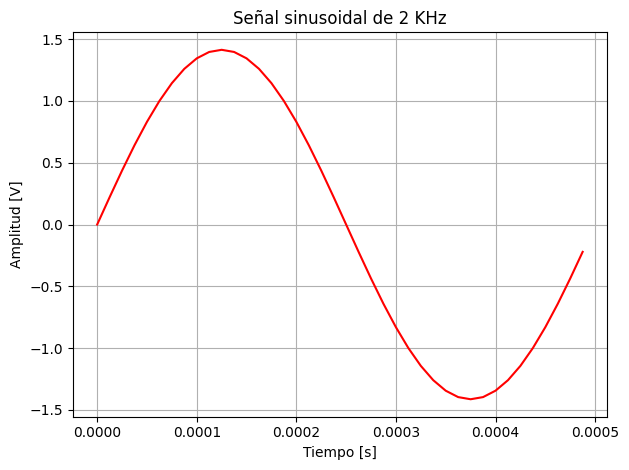

Período =  0.0005 segundos
Número de muestras =  40
Potencia =  1.0000000000000002 W


In [6]:
import matplotlib.pyplot as plt

plt.plot(tt, xx, color = 'red') 
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal sinusoidal de 2 KHz')
plt.grid(True)
plt.tight_layout()
plt.show()

potencia_senial=np.mean(xx**2) # Cálculo potencia

print('Período = ', T, 'segundos')
print('Número de muestras = ', nn)
print('Potencia = ', potencia_senial, 'W')

Para este primer caso, la señal sinusoidal tiene una frecuencia de 2KHz, su período es de 0.0005 segundos, derivado de la frecuencia de la señal, con una cantidad de muestras de 40 obtenido a partir del período junto con la frecuencia de muestreo.
Además, como la amplitud de la señal es $\sqrt{2}$, utilizando la fórmula de la potencia, obtenemos un resultado de 1 W. 
#### 2. Señal sinusoidal de 2KHz amplificada 3 dB y desfasada en π/2.
Defino los parámetros de la función y grafico. 

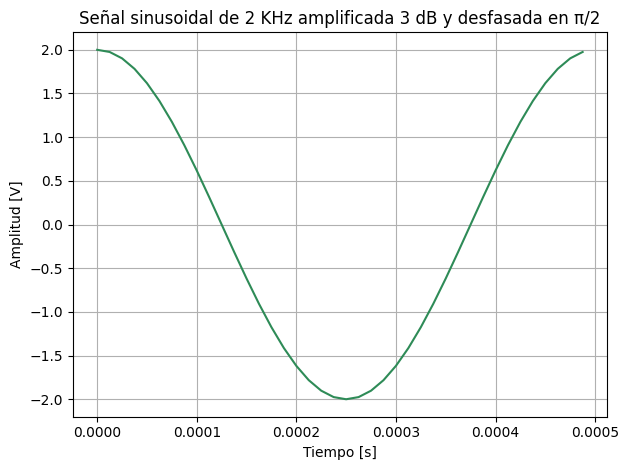

Período =  0.0005 segundos
Número de muestras =  40
Potencia =  1.9952623149688804 W


In [7]:
vmax = (10**(3/20)) * (np.sqrt(2)) # Amplificada 3 dB
dc = 0
ff = 2000
ph = np.pi/2
fs = 40*ff
T = 1/ff 
nn = int(T * fs)

tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)

plt.plot(tt, xx, color = 'seagreen') 
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal sinusoidal de 2 KHz amplificada 3 dB y desfasada en π/2')
plt.grid(True)
plt.tight_layout()
plt.show()

potencia_senial=np.mean(xx**2) # Cálculo potencia

print('Período = ', T, 'segundos')
print('Número de muestras = ', nn)
print('Potencia = ', potencia_senial, 'W')

Se puede observar la señal original amplificada 3 dB y desplazada en $\frac{π}{2}$, nuevamente con un período de 0.0005 segundos, resultante de la frecuencia de la señal y un número de muestras obtenido a partir del período junto con la frecuencia de muestreo. En este caso, el valor de la potencia es casi 2 W debido a la amplificación de la original. 
#### 3. Señal sinusoidal de 2KHz modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.

La ecuación matemática que describe a la señal con modulación de amplitud tradicional utilizada en este inciso es:

$$x(t) = A(t) \cdot sen(\omega_c \cdot t)$$ 

Siendo $$A(t) = a_x \cdot (1 + sen(\omega_m \cdot  t))$$ 

Donde:

•$A(t)$ es la envolvente que contiene la información.

•$a_x$ es la amplitud de la portadora.

•$sen(\omega_m  \cdot  t)$ es la señal moduladora, en este caso de  2 KHz.

•$sen(\omega_c  \cdot  t)$ es la señal portadora, en este ejercicio de 1000 KHz.

En el código, para mantener la amplitud de la señal original de 2 KHz como $\sqrt{2}$, se utilizó la ecuación previamente mencionada pero con dicho valor:

$$x(t) = (\sqrt{2} + \sqrt{2} \cdot \sin(\omega_m \cdot t)) \cdot (\sqrt{2} \cdot \sin(\omega_c \cdot t))$$

Extrayendo factor común $\sqrt{2}$, se obtiene la expresión final de la señal generada:

$$x(t) = (\sqrt{2} \cdot \sqrt{2}) \cdot (1 + \sin(\omega_m \cdot t)) \cdot \sin(\omega_c \cdot t)$$$$x(t) = 2 \cdot (1 + \sin(\omega_m \cdot t)) \cdot \sin(\omega_c \cdot t)$$

Por lo tanto, la amplitud de la portadora resulta ser $a_x = 2$ V. 

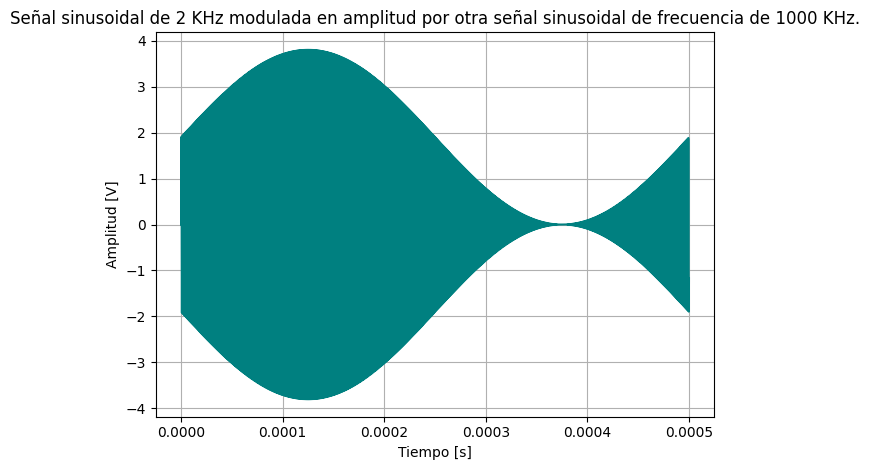

Período =  0.0005 segundos
Número de muestras =  5000
Potencia =  2.99999999999999 W


In [8]:
vmax = np.sqrt(2)
dc = 0
ph = 0
ff = 2000 # Frecuencia moduladora (2 KHz)
ff_portadora = 1000000 # Frecuencia portadora (1000 KHz)
fs = 10 * ff_portadora  
T = 1/ff 
nn = int(T * fs)

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)

tt, xx_portadora = mi_funcion_sen(vmax, dc, ff_portadora, ph, nn, fs)

xx_modulada = (vmax + xx) * (xx_portadora) 

plt.plot(tt, xx_modulada, color='teal')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal sinusoidal de 2 KHz modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.')
plt.grid(True)
plt.tight_layout()
plt.show()

potencia_senial=np.mean(xx_modulada**2) # Cálculo potencia

print('Período = ', T, 'segundos')
print('Número de muestras = ', nn)
print('Potencia = ', potencia_senial, 'W')

En este gráfico se observa una señal de 2 KHz que somete a un proceso de modulación a una señal de 1000 KHz. A esta última, se le llama portadora y oscila tan rápido que genera un efecto como si 'rellenara' el área del gráfico. Sin embargo, se puede notar que su amplitud máxima no es constante debido a que está delimitada por una envolvente, la cual tiene la misma forma y frecuencia de la señal sinusoidal original, es decir, de 2 KHz. 

A diferencia de los anteriores casos, el número de muestras aumenta a 5000 debido a que la frecuencia de muestreo es mucho más alta para que se pueda observar el fenómeno completo junto con la disminución de la amplitud. El período es de 0.0005 nuevamente. 

Además, la potencia de la señal resultante tiene un valor de aproximadamente 3 W debido a que está compuesta por la potencia de la portadora sumada con las bandas laterales de la moduladora.

#### 4. Señal sinusoidal de 2KHz con efecto de saturación al 75% de su amplitud.


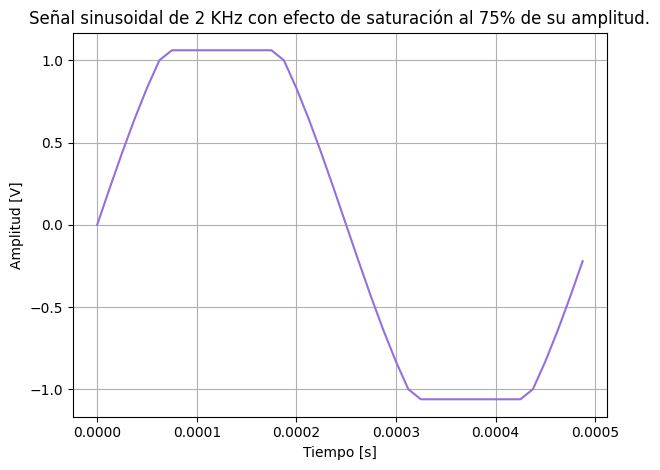

Período =  0.0005 segundos
Número de muestras =  40
Potencia =  0.740562424266248 W


In [9]:
vmax = np.sqrt(2)
dc = 0
ff = 2000
ph = 0
fs = 40*ff
T = 1/ff 
nn = int(T * fs)

tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)

limite = (75/100) * vmax # Defino 'techo' y 'piso'

xx_saturada = np.clip(xx, -limite, limite)     

plt.plot(tt, xx_saturada, color = 'mediumpurple')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal sinusoidal de 2 KHz con efecto de saturación al 75% de su amplitud.')
plt.grid(True)
plt.tight_layout()
plt.show()

potencia_senial=np.mean(xx_saturada**2) # Cálculo potencia

print('Período = ', T, 'segundos')
print('Número de muestras = ', nn)
print('Potencia = ', potencia_senial, 'W')

Para el cuarto inciso del primer ejercicio, se generó una señal sinusoidal de 2 KHz pero esta vez saturada al 75% de su amplitud. Al verse limitada, los picos de la onda senoidal no llegan a su máximo y se observa un valor constante. 

Si bien el período y el número de muestras se mantuvieron constantes con respecto a los gráficos previos, la potencia no. En este caso, tiene un valor cercano a 0.74 W. Este resultado tiene sentido debido a que al recortar los picos de la señal original, la señal transporta menos energía por ciclo. 


#### 5. Señal cuadrada de 4KHz.
Para empezar, defino la función cuadrada

In [10]:
from scipy import signal 

def mi_funcion_cuadrada(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs 
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * signal.square(2 * np.pi * ff * tt + ph) 
    return tt, xx

Posteriormente, defino los parámetros de la función y la grafico: 

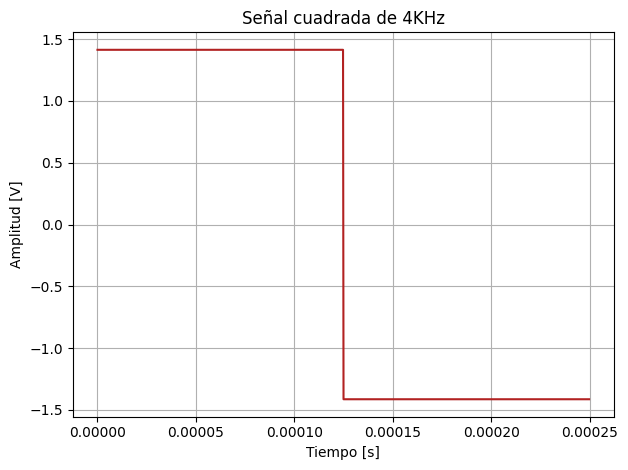

Período =  0.00025 segundos
Número de muestras =  1000
Potencia =  2.0000000000000004


In [11]:
vmax = np.sqrt(2)
dc = 0 
ff = 4000 
ph = 0 
fs = 1000*ff 
T = 1/ff 
nn = int(T * fs)

tt_cuadrada, xx_cuadrada = mi_funcion_cuadrada(vmax, dc, ff, ph, nn, fs)

plt.figure()
plt.plot(tt_cuadrada, xx_cuadrada, color='firebrick')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal cuadrada de 4KHz')
plt.grid(True)
plt.tight_layout()
plt.show()

potencia_senial=np.mean(xx_cuadrada**2) # Cálculo potencia

print('Período = ', T, 'segundos')
print('Número de muestras = ', nn)
print('Potencia = ', potencia_senial)

Para la señal cuadrada de 4 KHz, se obtuvo un período de 0.00025 con una cantidad de muestras de 1000. Ambos valores están relacionados a la frecuencia de la señal y a la frecuencia de muestreo. El valor obtenido para la potencia es de 2 W debido a que, a diferencia de la senoidal, la señal cuadrada se mantiene al máximo de su amplitud durante todo el ciclo, entregando mayor potencia que una onda sinusoidal de la misma amplitud.

#### 6. Pulso rectangular de 10ms.
Defino la función para el pulso rectangular: 

In [12]:
def mi_funcion_pulso_rect(vmax, dc, ancho, nn, fs):
    ts = 1 / fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * (tt <= ancho) 
    return tt, xx

Determino sus parámetros y la grafico: 

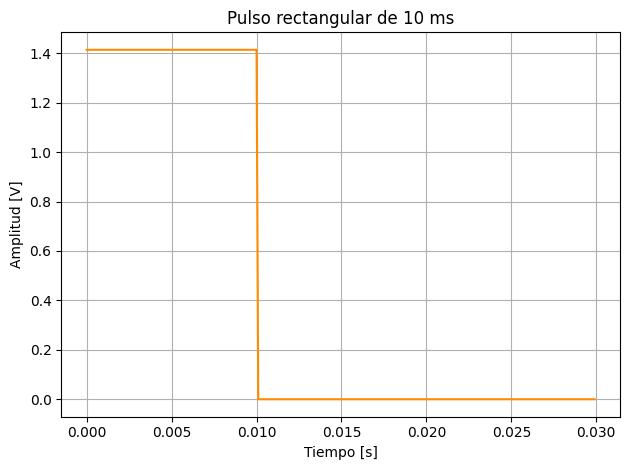

Número de muestras =  300


In [13]:
vmax = np.sqrt(2)
dc = 0
ancho = 0.010 # 10 ms 
fs = 10000    # Frecuencia de muestreo (10 kHz)
nn = 300      # 300 muestras a 10kHz = 0.03 segundos totales de gráfico

tt_rect, xx_rect = mi_funcion_pulso_rect(vmax, dc, ancho, nn, fs)

plt.figure()
plt.plot(tt_rect, xx_rect, color='darkorange') 
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Pulso rectangular de 10 ms')
plt.grid(True)
plt.tight_layout()
plt.show()

print('Número de muestras = ', nn)

En este último caso, al ser una señal aperiódica, no hay valor para el período y el número de muestras se eligió manualmente para poder observarlo correctamente al pulso rectangular. Además, se trata de una señal de energía con valor de potencia media nulo. 

## Ejercicio 2

Para este ejercicio, se comenzará mostrando gráficamente la función $h[n]$ y $x[n]$ en cada caso. 

Siendo $h[n] = \delta[n] - \delta[n-4]$


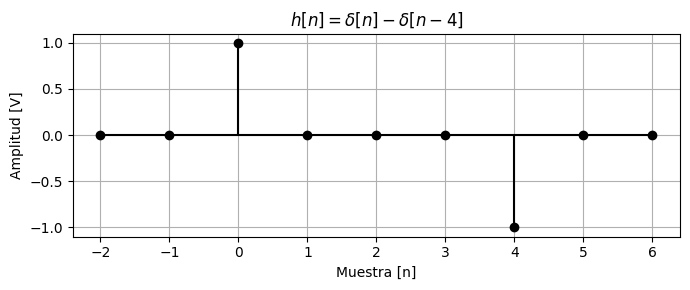

In [14]:
n = np.arange(-2, 7) 
hh = (n == 0)*1.0 - (n == 4)*1.0

plt.figure(figsize=(7, 3))
plt.stem(n, hh, basefmt="black", linefmt='black', markerfmt='ko')
plt.title('$h[n] = \delta[n] - \delta[n-4]$')
plt.xlabel('Muestra [n]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.tight_layout()
plt.show()

Es una función delta donde tiene valores nulos para todo valor de n excepto para $n = 0$ y $n = 4$.

Para el inciso $a)$, eligiendo valores para el gráfico de $x[n] = cos(ω₀.n. TS)$, obtenemos: 

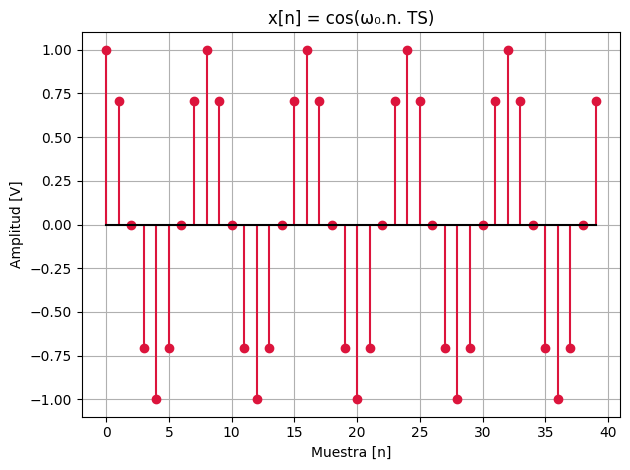

Frecuencia ff = 1000 Hz
Frecuencia de muestreo fs = 8000 Hz
Amplitud resultante (A) = 1
Fase resultante (phi) = 0 radianes


In [16]:
def mi_funcion_cos(ff, nn, fs):
    TS = 1 / fs
    n = np.arange(0, nn)
    w0 = 2 * np.pi * ff
    A = 1
    ph = 0
    xx = A * np.cos(w0 * n * TS + ph)
    return n, xx, A, ph
 
ff = 1000     # Frecuencia de la señal elegida
fs = 8000     # Frecuencia de muestreo elegida
nn = 40       # Cantidad de muestras a graficar

n_a, xx_a, A, fase_final = mi_funcion_cos(ff, nn, fs)

plt.stem(n_a, xx_a, basefmt="black", linefmt='crimson', markerfmt='crimson') 
plt.xlabel('Muestra [n]')
plt.ylabel('Amplitud [V]')
plt.title('x[n] = cos(ω₀.n. TS)')
plt.grid(True)
plt.tight_layout()
plt.show()

print('Frecuencia ff =', ff, 'Hz')
print('Frecuencia de muestreo fs =', fs, 'Hz')
print('Amplitud resultante (A) =', A)
print('Fase resultante (phi) =', fase_final, 'radianes')


Para el inciso $b)$, para el gráfico de $x[n] = (1/2)ⁿ * u[n]$ obtenemos: 

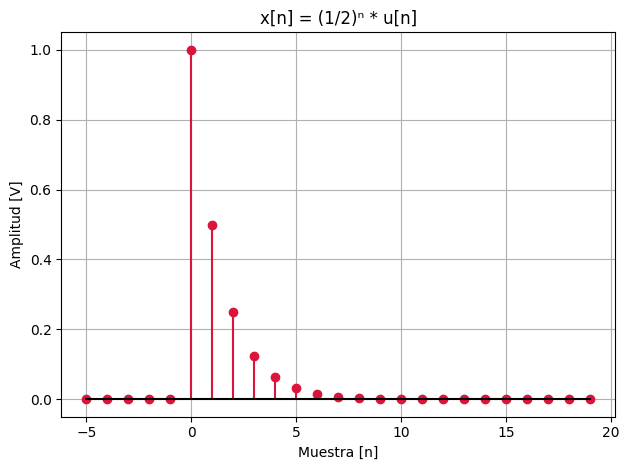

In [9]:
def mi_funcion_inciso_b(nn):
    n = np.arange(-5, nn - 5)
    xx = (0.5**n) * (n >= 0)
    return n, xx

nn = 25

n_b, xx_b = mi_funcion_inciso_b(nn)

plt.stem(n_b, xx_b, basefmt="black", linefmt='crimson', markerfmt='crimson') 
plt.xlabel('Muestra [n]')
plt.ylabel('Amplitud [V]')
plt.title('x[n] = (1/2)ⁿ * u[n]')
plt.grid(True)
plt.tight_layout()
plt.show()

Es una función exponencialmente decreciente, donde va tomando valores cada vez más cercanos al cero. 

Finalmente, en el inciso $c)$, para el gráfico de $x[n] = u[n + 1] - u[n - 2]$ obtenemos: 

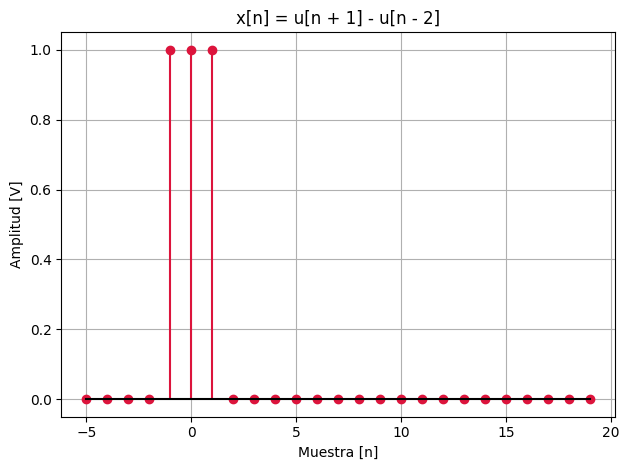

In [25]:
def mi_funcion_inciso_c(nn):
    n = np.arange(-5, nn - 5)
    xx = (n >= -1)*1.0 - (n >= 2)*1.0
    return n, xx

nn = 25 

n_c, x_c = mi_funcion_inciso_c(nn)

plt.stem(n_c, x_c, basefmt="black", linefmt='crimson', markerfmt='crimson') 
plt.xlabel('Muestra [n]')
plt.ylabel('Amplitud [V]')
plt.title('x[n] = u[n + 1] - u[n - 2]')
plt.grid(True)
plt.tight_layout()
plt.show()


Se puede observar como en los últimos tres gráficos cada función se muestrea como una suma de deltas. En este caso en particular, $u[n+1]$ es nula para todo $n < -1$. Al estar restándose con $u[n-2]$, la cual es 1 para todo $n ≥ 2$, a partir de $n = 2$ se cancelan mutuamente. 

A continuación, se muestra la resolución del ejercicio.

In [24]:
from IPython.display import IFrame
url_pdf = "https://raw.githubusercontent.com/egiuse25/APS/main/TS1_EJERCICIOS.pdf"
visor_google = f"https://docs.google.com/gview?url={url_pdf}&embedded=true"

IFrame(visor_google, width=1000, height=800)

Para las tres partes del ejercicio se utilizaron las propiedades de la convolución:

• $x[n] *  δ[n] = x[n]$

• $x[n] *  δ[n-k] = x[n-k]$

Esto quiere decir que en la función $h[n] = δ[n] - δ[n - 4]$ , al estar constituida por deltas (δ),  el primer término ($δ[n]$) opera como un elemento neutro de la convolución y, además, al convolucionar con un δ desplazado ($δ[n - 4]$) permite el desplazamiento de la señal original. 

Partiendo de que $$y[n] = x[n] * h[n]$$ se resolvió el ejercicio teniendo en cuenta que $$y[n] = x[n] - x[n-4]$$

A partir de esta ecuación, y como se evidencia en los gráficos posteriores, el efecto entonces de $h[n]$ sobre $x[n]$ equivale a tomar la señal original y restarle una versión de sí misma retrasada 4 muestras. 

Además, para el inciso $a)$ se utilizaron también propiedades trigonométricas enunciadas en el archivo previamente adjunto. 

Para corroborar los resultados dados, se los graficó a cada uno de ellos. 

#### Ejercicio 2.a)  $y[n] = (cos(ω₀.n. TS)) * (\delta[n] - \delta[n-4])$ 



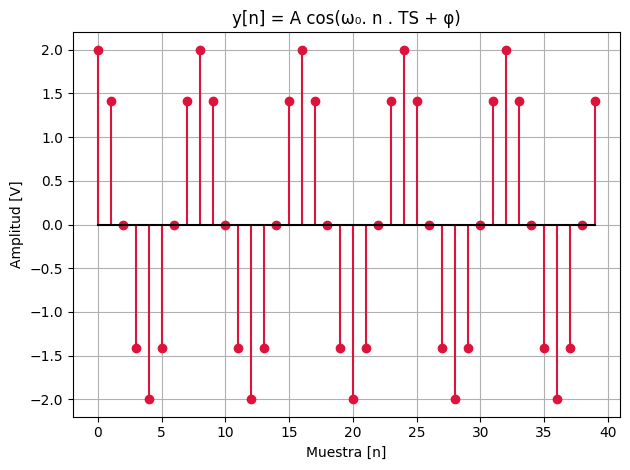

Frecuencia ff = 1000 Hz
Frecuencia de muestreo fs = 8000 Hz
Amplitud resultante (A) = 2.0
Fase resultante (phi) = 0.0 radianes


In [17]:
def mi_funcion_cos_conv(ff, nn, fs):
    TS = 1 / fs
    n = np.arange(0, nn)
    w0 = 2 * np.pi * ff
    A = 2 * np.sin(2 * w0 * TS)
    ph = -2 * w0 * TS + np.pi/2
    xx = A * np.cos(w0 * n * TS + ph)
    return n, xx, A, ph
 
ff = 1000     # Frecuencia de la señal elegida
fs = 8000     # Frecuencia de muestreo elegida
nn = 40       # Cantidad de muestras a graficar

n_a, xx_a, amplitud_final, fase_final = mi_funcion_cos_conv(ff, nn, fs)

plt.figure()
plt.stem(n_a, xx_a, basefmt="black", linefmt='crimson', markerfmt='crimson') 
plt.xlabel('Muestra [n]')
plt.ylabel('Amplitud [V]')
plt.title('y[n] = A cos(ω₀. n . TS + φ)')
plt.grid(True)
plt.tight_layout()
plt.show()

print('Frecuencia ff =', ff, 'Hz')
print('Frecuencia de muestreo fs =', fs, 'Hz')
print('Amplitud resultante (A) =', amplitud_final)
print('Fase resultante (phi) =', fase_final, 'radianes')

Para la primera parte del ejercicio, se eligieron valores de frecuencias para poder graficarlo, siendo de 1000 Hz la frecuencia y 8000 Hz la frecuencia de muestreo. 

Al ser una señal periódica y restarle una copia de sí misma un poco desfasada, las dos ondas se superponen y se mezclan en todos los puntos. Es decir, se genera un nuevo coseno. Si bien se obtuvo una fase resultante nula, al igual que en la función original antes de convolucionarla, la amplitud cambió y pasó a ser 2. 

#### Ejercicio 2.b)  $y[n] = ((1/2)ⁿ * u[n]) * (\delta[n] - \delta[n-4])$ 



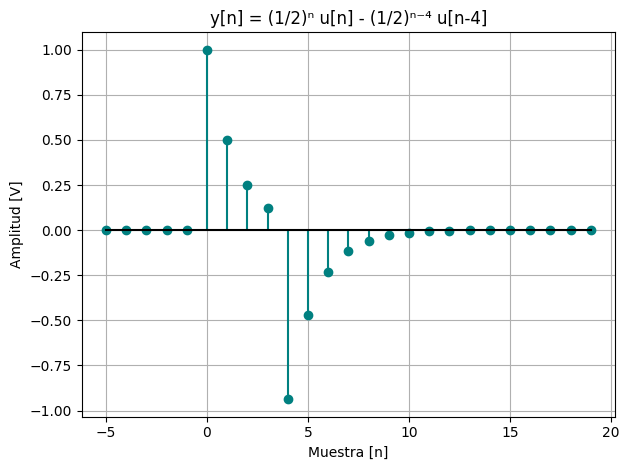

In [24]:
def mi_funcion_inciso_b_conv(nn):
    n = np.arange(-5, nn - 5)
    xx = (0.5**(n)) * (n >= 0) - (0.5**(n - 4)) * (n >= 4)
    return n, xx
    
nn = 25  

n_b, xx_b = mi_funcion_inciso_b_conv(nn)

plt.figure()
plt.stem(n_b, xx_b, basefmt="black", linefmt='teal', markerfmt='teal') 
plt.xlabel('Muestra [n]')
plt.ylabel('Amplitud [V]')
plt.title('y[n] = (1/2)ⁿ u[n] - (1/2)ⁿ⁻⁴ u[n-4]')
plt.grid(True)
plt.tight_layout()
plt.show()

En este caso, se observa la exponencial decreciente iniciando en $n = 0$, previamente observada en la señal original. A diferencia de esta última, esta señal se vuelve negativa a partir de la muestra $n = 4$. Esto es debido a que a partir de dicha muestra, el segundo término se vuelve mayor al primero decayendo asintóticamente a cero.

#### Ejercicio 2.c)  $y[n] = (u[n + 1] - u[n - 2]) * (\delta[n] - \delta[n-4])$ 

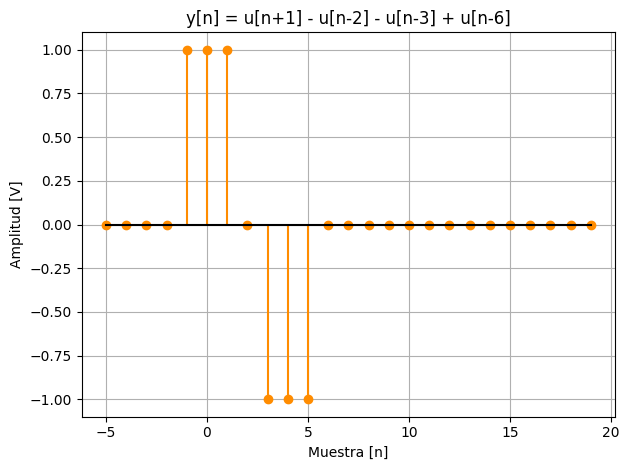

In [23]:
def mi_funcion_inciso_c_conv(nn):
    n = np.arange(-5, nn - 5)
    xx = (n >= -1)*1 - (n >= 2)*1 - (n >= 3)*1 + (n >= 6)*1
    return n, xx

nn = 25

n_c, xx_c = mi_funcion_inciso_c_conv(nn)

plt.figure()
plt.stem(n_c, xx_c, basefmt="black", linefmt='darkorange', markerfmt='darkorange') 
plt.xlabel('Muestra [n]')
plt.ylabel('Amplitud [V]')
plt.title('y[n] = u[n+1] - u[n-2] - u[n-3] + u[n-6]')
plt.grid(True)
plt.tight_layout()
plt.show()

En este último caso, si bien se construye un pulso positivo entre $n = -1$ y $n = 1$, al igual que en la señal original antes de la convolución, a partir de $n = 2$ se cancelan mutuamente. Esto mismo se repite para $u[n-3]$ con $u[n-6]$, formando un pulso idéntico al anterior pero negativo entre $n = 3$ y $n = 5$. 

# Conclusión 

Para el primer ejercicio, se puede notar a partir de los resultados obtenidos cómo las primeras cinco señales analizadas, es decir, la función cuadrada y las sinusoidales con sus variaciones, son señales de potencia debido a que son periódicas en el tiempo, y, por lo tanto, se propagan infinitamente.  Por otro lado, para el pulso rectangular de 10 ms, al ser una señal aperiódica y de duración limitada, es una señal de energía ya que su potencia media a lo largo del tiempo es nula, pero su energía total es un valor real y finito. Además se observó cómo la modulación, saturación y amplificación de la señal afectan a su forma y a su potencia. 

Con respecto al segundo ejercicio, el análisis se centró en la operación de convolución discreta, específicamente con un sistema definido por la respuesta al impulso $h[n] = \delta[n] - \delta[n-4]$. Se observó que convolucionar cualquier señal $x[n]$ con dicho sistema corresponde a tomar la misma señal pero restándole una copia de sí misma retrasada 4 muestras. 

En señales periódicas, como el coseno, el sistema modifica, en este caso, la amplitud de la señal resultante debido a la superposición y suma de los puntos de la señal original con los de la señal retrasada. 

En el resto de las señales, es decir, en la exponencial y los pulsos de los últimos dos incisos del segundo ejercicio, el efecto de retardo y resta genera la aparición de la señal original seguida de su versión invertida, cancelándose mutuamente en los tramos donde las muestras se superponen entre sí. 